# Task 2a: Corruption Classifier (Simple Baseline)

This notebook trains the **Convolutional Corruption Classifier** for Task 2a as required by the assignment.

### Mathematical Formulation
Given an input image $\tilde{x} \in \mathbb{R}^{3 \times 128 \times 128}$, the classifier computes posterior class probabilities across the four runtime conditions:
$$p = f(\tilde{x}) = [p_{clean},\, p_{salt},\, p_{blur},\, p_{occlusion}], \quad \sum_{k=1}^{4} p_k = 1$$
The predicted corruption class $\hat{k}$ is determined by argmax decision:
$$\hat{k} = \arg\max_{k}\, p_k$$

The classifier is trained using multiclass cross-entropy loss with balanced batches:
$$\mathcal{L}_{CE} = -\sum_{k=1}^{4} y_k \log p_k$$
where $y \in \{0, 1\}^4$ is the one-hot ground-truth corruption label generated by the runtime data loading pipeline.

In [3]:
# 1. Configuration & Hyperparameters
import os
TINY_RUN = False
TINY_SIZE = 50

BATCH_SIZE = 64
LR = 1e-3
BASE_CHANNELS = 32
DROPOUT = 0.2
EPOCHS = 2 if TINY_RUN else 20
SEED = 42

# Experiment tracking
USE_WANDB = bool(os.getenv("WANDB_API_KEY"))
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "genai-assignment")
WANDB_RUN_NAME = "task2a_classifier_simple"

In [4]:
# 2. Imports and Environment Setup
import sys
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

RESEARCH_ROOT = Path("..").resolve()
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

from constants import PET_IMAGES_DIR, CHECKPOINTS_MANIFEST
from src.device_utils import get_device, device_report
from src.datasets import PetDataset
from src.models_classifier import CorruptionClassifier
from src.train_loop import train_one_epoch_classifier, validate_classifier, set_seed
from src.checkpoint_utils import create_checkpoint_dict, save_checkpoint

set_seed(SEED)
device = get_device(verbose=True)

[device] Using GPU via CUDA: NVIDIA GeForce RTX 5050 Laptop GPU


In [5]:
# 3. Data Loading
mode_train = "tiny" if TINY_RUN else "train"
mode_val = "tiny" if TINY_RUN else "val"

train_dataset = PetDataset(mode=mode_train, corruption_mode="label", tiny_size=TINY_SIZE, seed=SEED)
val_dataset = PetDataset(mode=mode_val, corruption_mode="label", tiny_size=TINY_SIZE, seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"[Data] Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print(f"[Classes] {PetDataset.CLASSES}")

[Data] Train: 2944, Val: 736
[Classes] ['clean', 'salt', 'blur', 'occlusion']


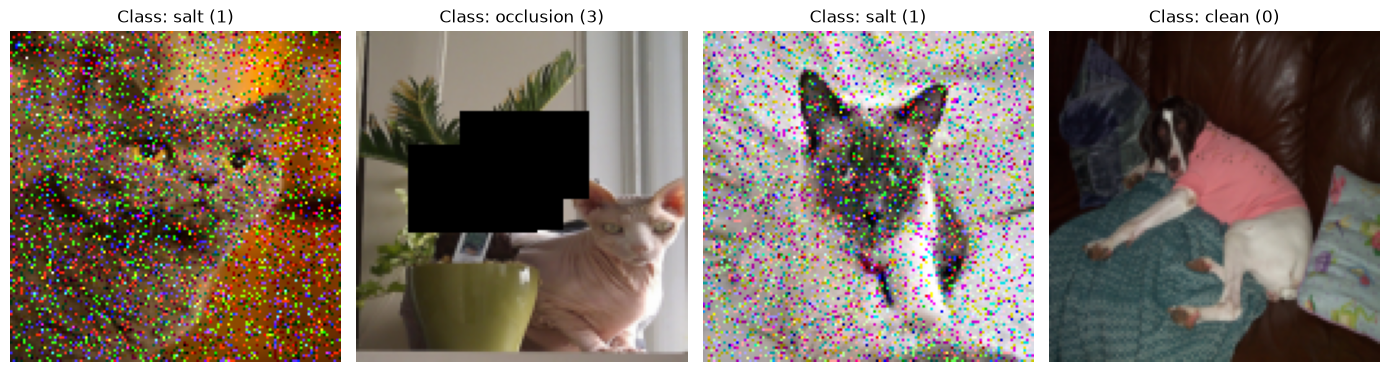

In [6]:
# 4. Inspect Sample Batches
sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(4):
    img = sample_imgs[i].permute(1, 2, 0).cpu().numpy().clip(0, 1)
    label_name = PetDataset.CLASSES[sample_labels[i].item()]
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {label_name} ({sample_labels[i].item()})")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# 5. Model & Optimizer Initialization
model = CorruptionClassifier(
    in_channels=3,
    base_channels=BASE_CHANNELS,
    dropout=DROPOUT,
    num_classes=4
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Model] CorruptionClassifier initialized with {total_params:,} parameters.")

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler('cuda') if device.type == "cuda" else None

[Model] CorruptionClassifier initialized with 724,516 parameters.


In [8]:
# 6. Training & Validation Loop
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
checkpoint_dir = RESEARCH_ROOT / "checkpoints"

print(f"--- Training Classifier for {EPOCHS} Epochs ---")
for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch_classifier(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        scaler=scaler
    )
    val_metrics = validate_classifier(
        model=model,
        loader=val_loader,
        device=device
    )

    for k in ["train_loss", "train_acc"]:
        history[k].append(train_metrics[k])
    for k in ["val_loss", "val_acc"]:
        history[k].append(val_metrics[k])

    val_acc = val_metrics["val_acc"]
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc

    ckpt_dict = create_checkpoint_dict(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        val_loss=val_metrics["val_loss"],
        random_seed=SEED,
        extra_metadata={"val_acc": val_acc}
    )
    save_checkpoint(
        checkpoint_dir=checkpoint_dir,
        prefix="task2_classifier",
        ckpt_dict=ckpt_dict,
        is_best=is_best,
        task_name="task2a",
        phase_name="simple",
        device_name=device_report()["device_name"]
    )

    print(
        f"Epoch [{epoch:02d}/{EPOCHS:02d}] "
        f"Train Loss: {train_metrics['train_loss']:.4f}, Train Acc: {train_metrics['train_acc']:.2%} | "
        f"Val Loss: {val_metrics['val_loss']:.4f}, Val Acc: {val_acc:.2%} {'*Best*' if is_best else ''}"
    )

print("--- Training Completed ---")

--- Training Classifier for 20 Epochs ---
Epoch [01/20] Train Loss: 1.1590, Train Acc: 41.85% | Val Loss: 0.8693, Val Acc: 50.27% *Best*
Epoch [02/20] Train Loss: 0.6461, Train Acc: 66.78% | Val Loss: 0.5021, Val Acc: 78.40% *Best*
Epoch [03/20] Train Loss: 0.4707, Train Acc: 74.83% | Val Loss: 0.3970, Val Acc: 81.11% *Best*
Epoch [04/20] Train Loss: 0.3720, Train Acc: 81.86% | Val Loss: 0.3316, Val Acc: 85.46% *Best*
Epoch [05/20] Train Loss: 0.5618, Train Acc: 71.37% | Val Loss: 0.4784, Val Acc: 71.33% 
Epoch [06/20] Train Loss: 0.3886, Train Acc: 80.26% | Val Loss: 0.3284, Val Acc: 83.42% 
Epoch [07/20] Train Loss: 0.3563, Train Acc: 83.87% | Val Loss: 0.3172, Val Acc: 83.29% 
Epoch [08/20] Train Loss: 0.2984, Train Acc: 86.51% | Val Loss: 0.2290, Val Acc: 91.17% *Best*
Epoch [09/20] Train Loss: 0.1840, Train Acc: 92.97% | Val Loss: 0.1886, Val Acc: 93.89% *Best*
Epoch [10/20] Train Loss: 0.1544, Train Acc: 94.60% | Val Loss: 0.1461, Val Acc: 95.24% *Best*
Epoch [11/20] Train Loss: 

              precision    recall  f1-score   support

       clean       0.98      0.92      0.95       183
        salt       1.00      1.00      1.00       179
        blur       0.93      0.98      0.95       178
   occlusion       0.99      1.00      1.00       196

    accuracy                           0.98       736
   macro avg       0.98      0.98      0.98       736
weighted avg       0.98      0.98      0.98       736



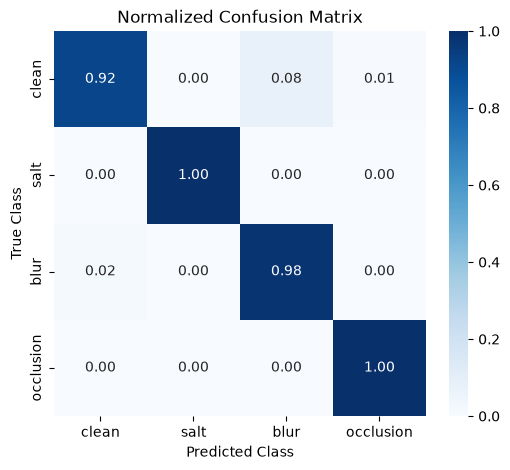

In [9]:
# 7. Confusion Matrix & Classification Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_results = validate_classifier(model, val_loader, device)
y_true = val_results["labels"]
y_pred = val_results["preds"]

print(classification_report(y_true, y_pred, target_names=PetDataset.CLASSES))

cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=PetDataset.CLASSES, yticklabels=PetDataset.CLASSES)
plt.title("Normalized Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

## 8. Transition Gate Checklist (Plan 6 §2a.4)
- [ ] Validation accuracy clearly above random chance (>60% sanity threshold).
- [ ] No single class collapsing to ~0% recall.
- [ ] Checkpoint `task2_classifier_best.pt` saved and loadable for Task 3 initialization.